# Part 7: Training From Scratch

In [1]:
# @title Setup { display-mode: "form" }

import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

print(f"JAX version:     {jax.__version__}")
print(f"Devices:         {jax.devices()}")
print(f"Default backend: {jax.default_backend()}")

JAX version:     0.9.2
Devices:         [CpuDevice(id=0)]
Default backend: cpu


In [2]:
# @title Shared Data and From-Scratch Utilities { display-mode: "form" }

# Dataset - two interleaved half-moons
key = jax.random.key(42)

def make_moons(n_samples=1000, noise=0.15, seed=0):
    rng = np.random.default_rng(seed)
    n = n_samples // 2
    t = np.linspace(0, np.pi, n)
    X0 = np.c_[np.cos(t), np.sin(t)]                        # upper moon
    X1 = np.c_[1 - np.cos(t), 1 - np.sin(t) - 0.5]         # lower moon
    X = np.vstack([X0, X1]) + rng.normal(scale=noise, size=(n_samples, 2))
    y = np.hstack([np.zeros(n), np.ones(n)])
    return X.astype(np.float32), y.astype(np.float32)

X_np, y_np = make_moons(n_samples=1000, noise=0.15, seed=0)
X = jnp.array(X_np)
y = jnp.array(y_np)

# From-scratch MLP utilities (carried over from Notebook 05)
def init_mlp_params(key, layer_sizes):
    params = []
    for n_in, n_out in zip(layer_sizes[:-1], layer_sizes[1:]):
        key, w_key = jax.random.split(key)
        w = jax.random.normal(w_key, (n_in, n_out)) * jnp.sqrt(2.0 / n_in)
        b = jnp.zeros(n_out)
        params.append({'w': w, 'b': b})
    return params

def mlp_forward(params, x):
    for layer in params[:-1]:
        x = jnp.maximum(x @ layer['w'] + layer['b'], 0)  # ReLU
    last = params[-1]
    return (x @ last['w'] + last['b']).squeeze(-1)

print("Shared dataset and MLP utilities initialized.")
print(f"X shape: {X.shape}, y shape: {y.shape}")

Shared dataset and MLP utilities initialized.
X shape: (1000, 2), y shape: (1000,)


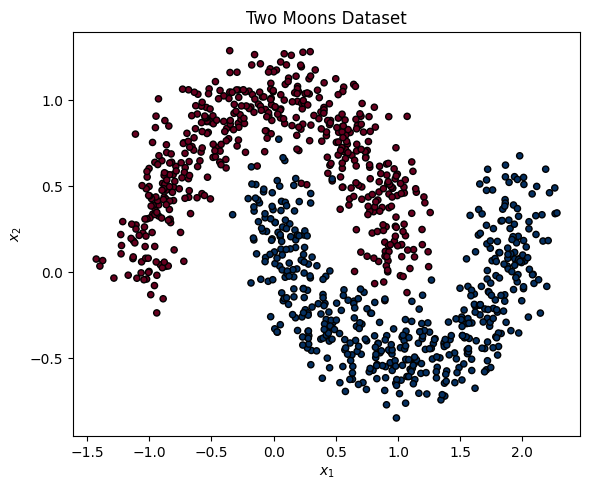

In [3]:
# @title Visualize the dataset { display-mode: "form" }
plt.figure(figsize=(6, 5))
plt.scatter(X_np[:, 0], X_np[:, 1], c=y_np, cmap='RdBu', edgecolors='k', s=20)
plt.title('Two Moons Dataset')
plt.xlabel('$x_1$'); plt.ylabel('$x_2$')
plt.tight_layout()
plt.show()

---

# 1. What is Neural Network Training?

## 1.1 The Dataset: Two Moons

The dataset we'll use is called **two moons**: 1,000 points arranged as two interleaved crescent shapes (see the scatter plot above), coloured by class (0 or 1). A straight line can't separate them, so the model has to learn a curved boundary. The goal: given a 2D point `(x, y)`, predict which class it belongs to.

## 1.2 The Training Loop

Training a neural network is a three-step loop repeated thousands of times:

```
  1. Forward pass   → run the input through the network, get a prediction
  2. Loss           → measure how wrong the prediction is (one number)
  3. Gradient step  → nudge each weight slightly in the direction that reduces loss

  Repeat until loss is small enough.
```

The third step is called **gradient descent**. The gradient for a weight is the slope of the loss when you nudge that weight up: positive gradient means "increasing this weight makes the loss bigger", negative means "increasing this weight makes the loss smaller". To reduce loss we want to go the opposite way, so we *subtract* a small multiple of the gradient. That small multiple is the **learning rate**.

In JAX:
- `jax.value_and_grad(loss_fn)(params, x, y)` computes both the loss value and the gradient

- `jax.tree.map(lambda p, g: p - lr * g, params, grads)` applies the update to every weight

That's the entire from-scratch training loop.

---

# 2. Training from Scratch

Putting the pieces together: pytree parameters, vmap for batching, jit for speed. Let's assemble a complete training loop, no frameworks.

```
  Previous params ──► Forward pass ──► Loss value
                                           │
                                       jax.grad
                                           │
                                           ▼
  New params ◄── SGD update ◄──────── Gradients
       │
       └──► (repeat)
```

The loss function we'll use is **binary cross-entropy**: the standard choice for predicting one of two classes. JAX gives us a one-line, numerically safe form; you don't need to derive it.

> **What are "logits"?** Our network outputs a single raw number per input, *before* it's squashed into a probability. That raw score is called a **logit**. To turn a logit into a probability between 0 and 1, you pass it through the **sigmoid** function (`jax.nn.sigmoid`): an S-shaped curve where large positive logits map near 1, large negative logits near 0, and 0 maps to 0.5. Binary cross-entropy measures how far these predicted probabilities are from the true 0/1 labels. The formula below folds the sigmoid step inside it for numerical stability, so it takes the raw logits directly rather than probabilities.

In [4]:
# Loss function: binary cross-entropy
def binary_cross_entropy(params, x_batch, y_batch):
    logits = jax.vmap(mlp_forward, in_axes=(None, 0))(params, x_batch)
    loss = jnp.mean(
        jnp.maximum(logits, 0) - logits * y_batch + jnp.log(1 + jnp.exp(-jnp.abs(logits)))
    )
    return loss

# JIT-compiled training step with pytree SGD update
@jax.jit
def train_step_scratch(params, x_batch, y_batch, lr=0.05):
    loss, grads = jax.value_and_grad(binary_cross_entropy)(params, x_batch, y_batch)
    # tree.map applies the SGD update to every weight and bias leaf
    new_params = jax.tree.map(lambda p, g: p - lr * g, params, grads)
    return new_params, loss

# Initialize and train
key, subkey = jax.random.split(key)
params_scratch = init_mlp_params(subkey, [2, 64, 64, 1])

losses_scratch = []
# Each iteration is one gradient *step* on a random 128-point mini-batch
# (a small random subset of the data), not a full pass over the dataset.
for step in range(200):
    key, subkey = jax.random.split(key)
    idx = jax.random.permutation(subkey, len(X))[:128]
    params_scratch, loss = train_step_scratch(params_scratch, X[idx], y[idx])
    losses_scratch.append(loss.item())
    if step % 20 == 0:
        print(f"Step {step:3d}: loss = {loss:.4f}")

Step   0: loss = 1.1545
Step  20: loss = 0.3071
Step  40: loss = 0.3300
Step  60: loss = 0.1836
Step  80: loss = 0.3590
Step 100: loss = 0.2635
Step 120: loss = 0.2272
Step 140: loss = 0.2586
Step 160: loss = 0.2512
Step 180: loss = 0.2768


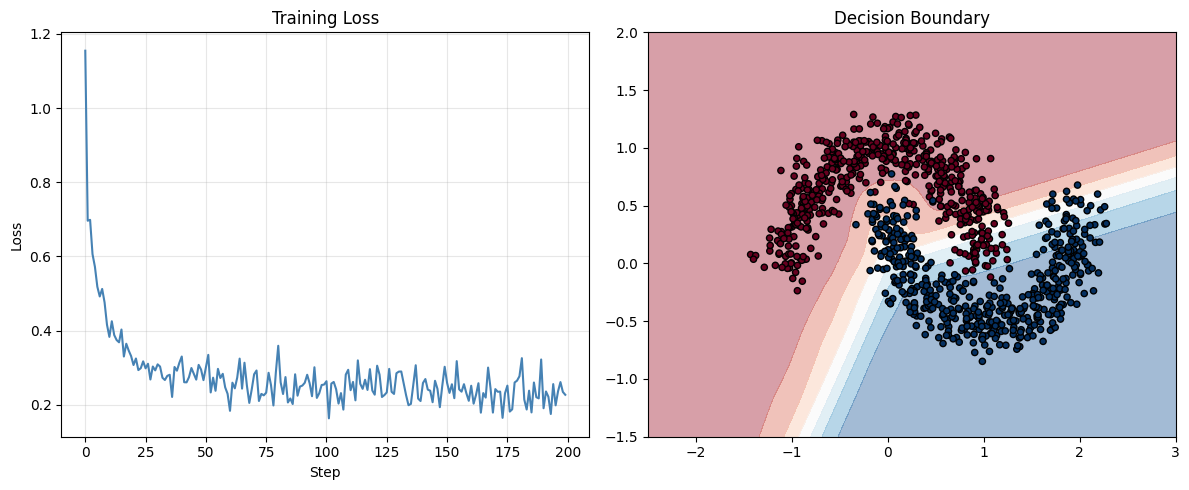

In [5]:
# @title Loss curve and decision boundary { display-mode: "form" }
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Loss curve
axes[0].plot(losses_scratch, color='steelblue')
axes[0].set_xlabel('Step'); axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss'); axes[0].grid(alpha=0.3)

# Decision boundary
xx, yy = np.meshgrid(np.linspace(-2.5, 3, 200), np.linspace(-1.5, 2, 200))
grid = jnp.array(np.c_[xx.ravel(), yy.ravel()], dtype=jnp.float32)
logits = jax.vmap(mlp_forward, in_axes=(None, 0))(params_scratch, grid)
probs = jax.nn.sigmoid(logits).reshape(xx.shape)
axes[1].contourf(xx, yy, np.array(probs), alpha=0.4, cmap='RdBu')
axes[1].scatter(X_np[:, 0], X_np[:, 1], c=y_np, cmap='RdBu', edgecolors='k', s=20)
axes[1].set_title('Decision Boundary')
plt.tight_layout(); plt.show()

---

# 3. The Boilerplate Problem

The from-scratch approach works, but imagine scaling it:

```python
# 3 layers: manageable
params = init_mlp_params(key, [2, 64, 64, 1])

# A realistic model has dozens of layers and several layer *types* (not just dense).
# You'd write hundreds of lines of shape arithmetic before training a single step.
```

The real cost isn't the parameter update. It's **manually computing shapes** for every layer, **manually organizing** the nested dict, and **manually implementing** common layer types like convolution or normalization.

**Flax** (`flax.linen`) solves exactly this. It:
- Infers shapes automatically from a dummy input

- Names parameters consistently

- Provides common layers (`nn.Dense`, `nn.LayerNorm`, `nn.MultiHeadAttention`, ...)

**Flax does not change the JAX model.** `params` is still a pytree. `jax.tree.map` still updates it. `jax.value_and_grad` still computes gradients. Flax just manages the creation and structure of that pytree.

---

# 4. Summary

## Key Takeaways

- **Training is purely functional**: a training step is a pure function that takes parameters and data, computes loss and gradients, and returns updated parameters.

- **Boilerplate is the real cost**: manually defining weight shapes, initializing nested parameter dictionaries, and writing explicit layers is tedious and error-prone at any real scale.

- **Libraries exist to solve this**: raw JAX is the execution engine; high-level libraries (Flax, Optax) manage model architecture and optimization.

## What's Next

In **Notebook 08: Flax Basics**, we'll replace `init_mlp_params` with `nn.Module` and see that the underlying pytree (and therefore everything you learned about `grad` and `tree.map`) is unchanged.

---

# 5. Exercises

1. **Learning rate sensitivity**: Train the same network with `lr=0.001`, `lr=0.05`, and `lr=0.5`. How does the loss curve change? What happens with a very high learning rate?

2. **Architecture size**: Change the hidden layer sizes from `[2, 64, 64, 1]` to `[2, 16, 1]` (much smaller) and `[2, 256, 256, 256, 1]` (much larger). How does final loss compare?

3. **Batch size experiments**: Experiment with the training loop by changing the batch size to 2 and then to 100. How does it affect the speed and final loss?